# Laboratorio di Simulazione Numerica - Notebook 1

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

## Esercizio 01.1

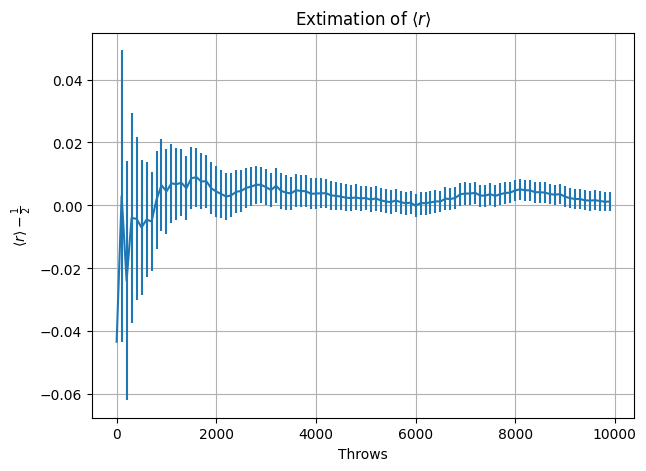

In [13]:
data = np.loadtxt("01.1/averages.out")
averages = data[:, 0]
errors = data[:, 1]
L = 100

x = np.arange(averages.size) * L

fig, ax = plt.subplots(1, 1, figsize=(7,5))

ax.errorbar(x, averages - 0.5, yerr=errors)
ax.set_title(r"Extimation of $\langle r\rangle$")
ax.set_xlabel("Throws")
ax.set_ylabel(r"$\langle r\rangle-\frac{1}{2}$")
ax.grid();

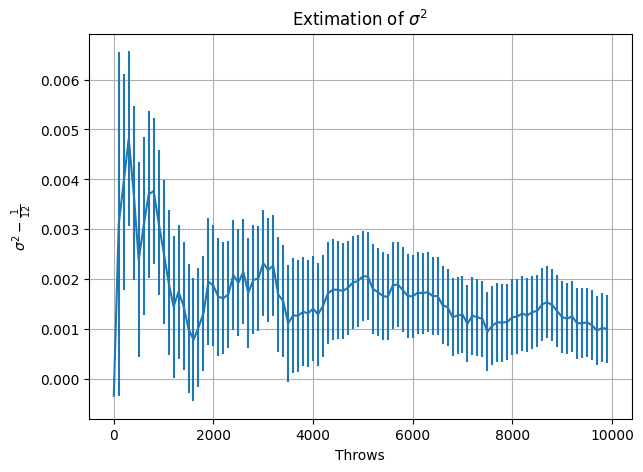

In [14]:
data = np.loadtxt("01.1/variances.out")
variances = data[:, 0]
errors = data[:, 1]
L = 100

x = np.arange(variances.size) * L

fig, ax = plt.subplots(1, 1, figsize=(7,5))

ax.errorbar(x, variances - 1./12., yerr=errors)
ax.set_title(r"Extimation of $\sigma^2$")
ax.set_xlabel("Throws")
ax.set_ylabel(r"$\sigma^2-\frac{1}{12}$")
ax.grid();

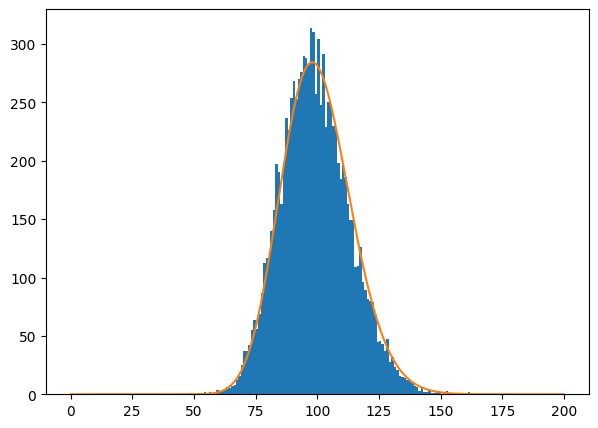

In [ ]:
chi2 = np.loadtxt("01.1/chi2.out")

fig, ax = plt.subplots(1, 1, figsize=(7,5))
xmin, xmax = 0.1, 200
nbins = 200
x = np.arange(xmin, xmax, 0.1)


ax.hist(chi2, bins=nbins, range=(xmin,xmax));
k = 100

ax.plot(x, chi2.size * ((xmax-xmin)/nbins) * np.power(x, k*0.5-1)*np.exp(-x*0.5)/(np.power(2, k*0.5)*math.gamma(k*0.5)));

LEGENDA!

## Esercizio 01.2

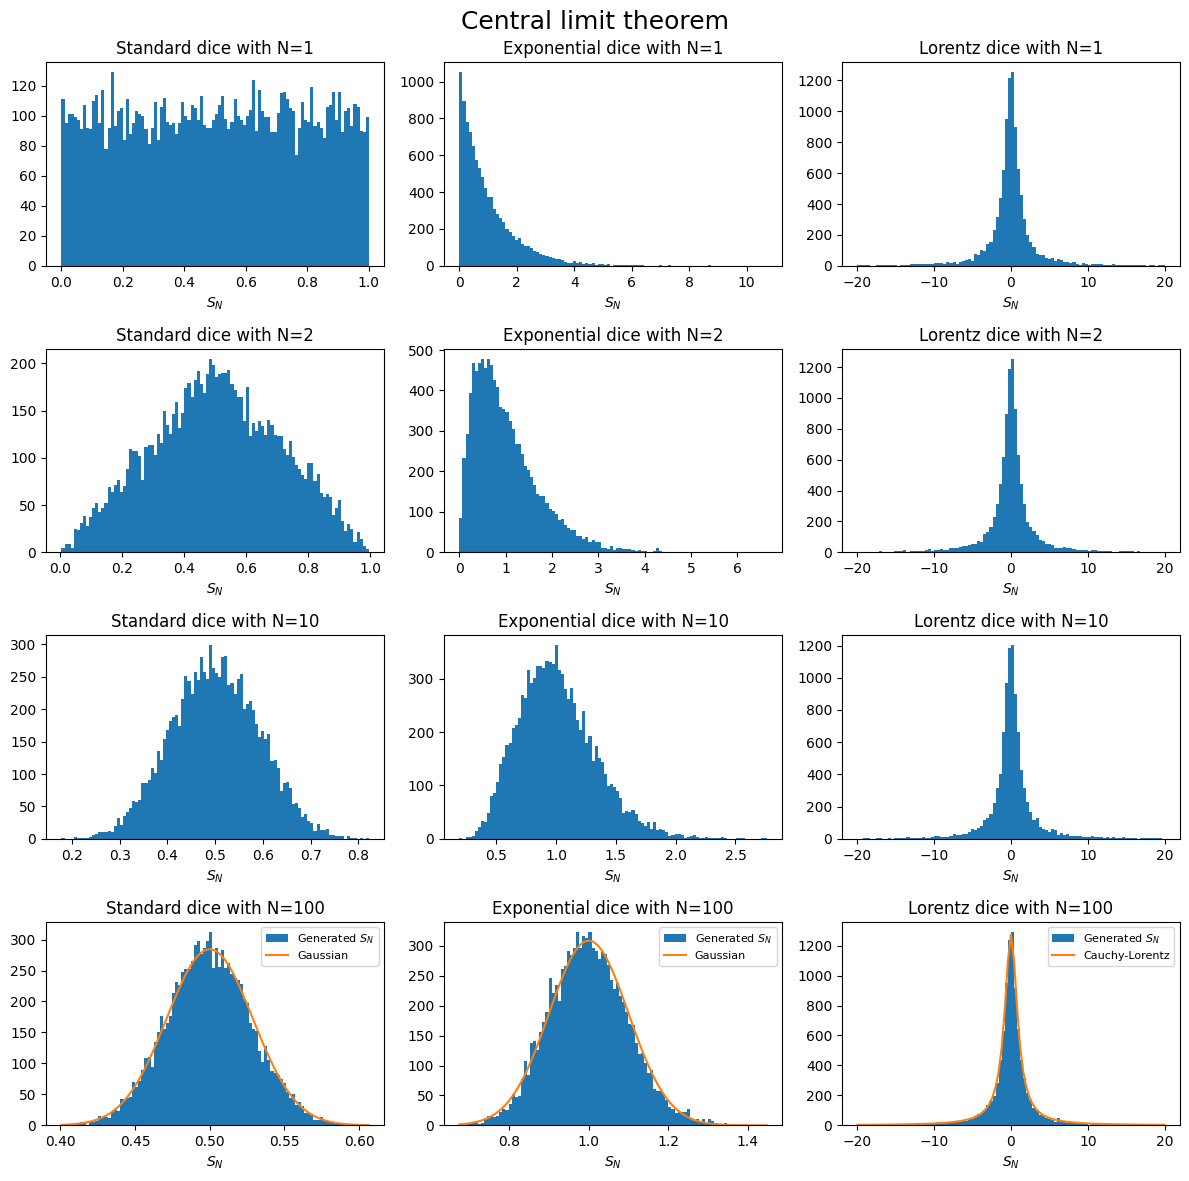

In [8]:
N = [1, 2, 10, 100]
nbins = 100
nsamples = 10000

fig, axs = plt.subplots(4, 3, figsize=(12,12))
fig.suptitle("Central limit theorem", fontsize=18)

for row, n in enumerate(N):
    data = np.loadtxt(f"01.2/{n}.out")
    standard, exp, lorentz = data[:,0], data[:,1], data[:,2]

    _, bins_standard, _ = axs[row,0].hist(standard, nbins, label="Generated $S_N$")
    _, bins_exp, _ = axs[row,1].hist(exp, nbins,label="Generated $S_N$")
    _, bins_lorentz, _ = axs[row,2].hist(lorentz, nbins, range=(-20,20),label="Generated $S_N$")

    axs[row,0].set_title(f"Standard dice with N={n}")
    axs[row,1].set_title(f"Exponential dice with N={n}")
    axs[row,2].set_title(f"Lorentz dice with N={n}")

    for ax in axs[row,:]:
        ax.set_xlabel("$S_N$")

    # fit theorical distributions for N=100
    if row == 3:
        x = bins_standard
        axs[row,0].plot(x, nsamples*(x[1]-x[0])*np.exp(-np.power(x-0.5,2)*n*12./2.)*math.sqrt(n*12./(2.*np.pi)), label="Gaussian")

        x = bins_exp
        axs[row,1].plot(x, nsamples*(x[1]-x[0])*np.exp(-np.power(x-1.,2)*n/2.)*math.sqrt(n/(2.*np.pi)), label="Gaussian")

        x = bins_lorentz
        axs[row,2].plot(x, nsamples*(x[1]-x[0])/(np.pi*(1+np.power(x,2))), label="Cauchy-Lorentz")

        for ax in axs[row,:]:
            ax.legend(loc="upper right", fontsize=8);

plt.tight_layout();


## Esercizio 01.3

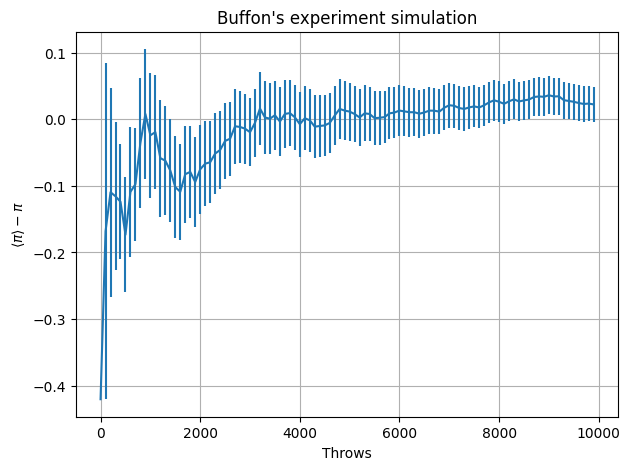

In [5]:
data = np.loadtxt("01.3/pi.out")
pi = data[:, 0]
errors = data[:, 1]

x = np.arange(pi.size) * 100

fig, ax = plt.subplots(1, 1, figsize=(7,5))

ax.errorbar(x, pi - np.pi, yerr=errors)
ax.set_title("Buffon's experiment simulation")
ax.set_xlabel("Throws")
ax.set_ylabel(r"$\langle\pi\rangle-\pi$")
ax.grid()

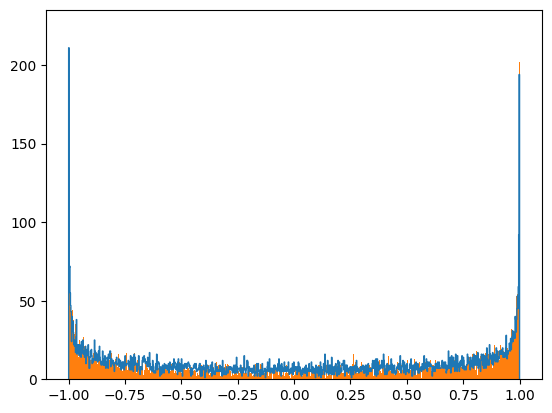

In [30]:
N = 10000
nbins = 1000
angles = np.random.uniform(-np.pi, np.pi, size=N)
cosines = (1-np.power(np.random.random(size=N),2))*np.random.choice([-1,1], size=N)
signs =np.random.choice([-1,1], size=N)
plt.hist(np.cos(angles), bins=nbins, histtype="step");
#plt.hist(signs*np.sqrt(1-np.power(np.cos(angles), 2)), bins=nbins, histtype="step");
#plt.hist(np.sin(angles), bins=nbins, histtype="step");
plt.hist(cosines, bins=nbins);